## CW 信号 + CBF 仿真

目标：先用最基础的常规波束形成（Conventional Beamforming, CBF，也就是 delay-and-sum）验证远场窄带 DOA 估计流程。

这里采用水声远场窄带模型，信号为 `30 kHz` CW 单频信号，阵列为 `16` 阵元均匀线阵（ULA）。角度定义为相对阵列法线 broadside 的入射角：`0 deg` 表示正前方，`+theta` 表示沿阵元位置正方向产生递增传播时延。

## 参数设置

- 声速 `c = 1500 m/s`：典型水声仿真默认值，真实海水会随温盐深变化。
- 载频 `fc = 30 kHz`：题设 CW 窄带信号。
- 波长 `lambda = c / fc = 0.05 m`。
- 阵元数 `M = 16`：题设。
- 阵元间距 `d = lambda / 2 = 0.025 m`：避免空间混叠和栅瓣，是窄带 ULA 的常用起点。
- 阵列孔径 `D = (M - 1) d = 0.375 m`。
- 远场距离量级 `R >> 2D^2 / lambda`，本例约 `5.6 m`，所以几十米外可近似为平面波。
- 采样率 `fs = 240 kHz`：为载频 8 倍，足够生成和可视化 CW；若只做复基带仿真，采样率主要影响快拍数。
- 观测时长 `duration = 20 ms`：得到 `4800` 个快拍，CBF 谱比较稳定。
- 信噪比 `SNR = 10 dB`：先用中等噪声观察主瓣，再可改成 `0/20 dB` 看鲁棒性。
- 扫描范围 `[-90 deg, 90 deg]`，步长 `1 deg`：线阵 broadside 模型的常见扫描范围。

## 窄带远场阵列模型

均匀线阵第 `m` 个阵元位置为 `x_m`。对入射角 `theta`，远场平面波相对第 0 个阵元的时延为

$tau_m(\theta) = x_m sin(\theta) / c$

对应窄带 steering vector：

$a_m(\theta) = exp(-j 2 pi fc \tau_m(\theta))$

接收数据矩阵：

$X = a(\theta_0) s(t) + W$

CBF 扫描功率：

$P(\theta) = a(\theta)^H Rxx a(\theta) / M^2`，其中 `Rxx = X X^H / N$

In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# Reproducible random noise.
rng = np.random.default_rng(20260602) # Seed for reproducibility. Random Number Generator

# -----------------------------
# 1. Physical and array settings
# -----------------------------
c = 1500.0              # sound speed in water, m/s
fc = 30e3               # CW carrier frequency, Hz
wavelength = c / fc     # wavelength, m

M = 16                  # number of ULA elements
d = wavelength / 2      # half-wavelength spacing avoids grating lobes
positions = np.arange(M) * d
aperture = positions[-1] - positions[0] # 阵列孔径
far_field_distance = 2 * aperture**2 / wavelength

# -----------------------------
# 2. Signal and observation settings
# -----------------------------
theta_true_deg = 25.0   # true DOA relative to broadside, deg
fs = 240e3              # sampling rate, Hz
duration = 0.020        # observation duration, s
snr_db = 10.0           # sensor-level SNR, dB

t = np.arange(0, duration, 1 / fs)
N = t.size

print(f"fc = {fc / 1e3:.1f} kHz")
print(f"lambda = {wavelength:.4f} m")
print(f"M = {M}, d = {d:.4f} m = {d / wavelength:.2f} lambda")
print(f"array aperture D = {aperture:.4f} m")
print(f"far-field reference 2D^2/lambda = {far_field_distance:.2f} m")
print(f"snapshots N = {N}, duration = {duration * 1e3:.1f} ms, fs = {fs / 1e3:.1f} kHz")


fc = 30.0 kHz
lambda = 0.0500 m
M = 16, d = 0.0250 m = 0.50 lambda
array aperture D = 0.3750 m
far-field reference 2D^2/lambda = 5.62 m
snapshots N = 4800, duration = 20.0 ms, fs = 240.0 kHz


In [12]:
def steering_vector(theta_deg, fc, c, positions):
    """ULA steering vector for a far-field narrowband plane wave."""
    theta = np.deg2rad(theta_deg)
    tau = positions * np.sin(theta) / c
    return np.exp(-1j * 2 * np.pi * fc * tau)

# 对称的复数高斯噪声，功率为噪声功率的一半（实部和虚部各占一半）。
def add_complex_awgn(signal_matrix, snr_db, rng):
    """Add circular complex white Gaussian noise at the requested SNR."""
    signal_power = np.mean(np.abs(signal_matrix) ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.sqrt(noise_power / 2) * (
        rng.standard_normal(signal_matrix.shape) + 1j * rng.standard_normal(signal_matrix.shape)
    ) #标准正态分布的随机数生成器，生成与信号矩阵形状相同的复数噪声矩阵。
    return signal_matrix + noise


# Complex analytic CW. This is equivalent to using the narrowband complex envelope.
s = np.exp(1j * 2 * np.pi * fc * t)
a_true = steering_vector(theta_true_deg, fc, c, positions)

X_clean = a_true[:, None] * s[None, :] # None 将一维数组分别变成行向量、列向量，Mx1 * 1xN -> MxN
X = add_complex_awgn(X_clean, snr_db=snr_db, rng=rng)

print(f"X shape = {X.shape}  # (sensors, snapshots)")
print(f"true DOA = {theta_true_deg:.1f} deg, SNR = {snr_db:.1f} dB")


X shape = (16, 4800)  # (sensors, snapshots)
true DOA = 25.0 deg, SNR = 10.0 dB


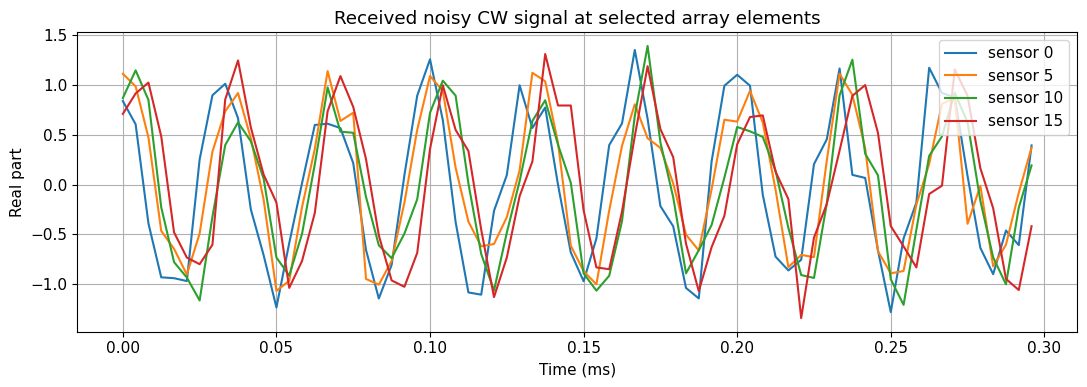

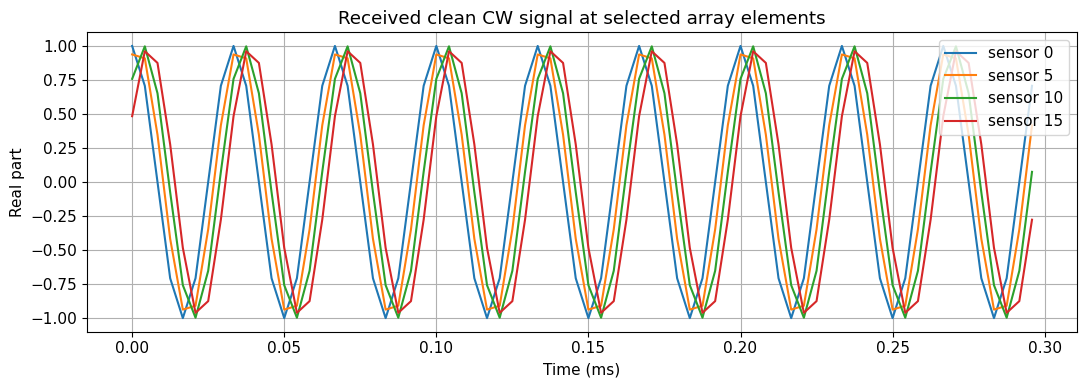

In [21]:
# Plot a short segment of the received real part at several sensors.
samples_to_show = int(0.30e-3 * fs)  # 0.3 ms, about 9 cycles at 30 kHz
sensor_ids = [0, 5, 10, 15]

plt.figure(figsize=(11, 4))
for m in sensor_ids:
    plt.plot(t[:samples_to_show] * 1e3, np.real(X[m, :samples_to_show]), label=f"sensor {m}")

plt.xlabel("Time (ms)")
plt.ylabel("Real part")
plt.title("Received noisy CW signal at selected array elements")
plt.legend(loc="upper right")
plt.tight_layout()

plt.figure(figsize=(11, 4))
for m in sensor_ids:
    plt.plot(t[:samples_to_show] * 1e3, np.real(X_clean[m, :samples_to_show]), label=f"sensor {m}")

plt.xlabel("Time (ms)")
plt.ylabel("Real part")
plt.title("Received clean CW signal at selected array elements")
plt.legend(loc="upper right")
plt.tight_layout()


In [25]:
def cbf_spectrum(X, scan_angles_deg, fc, c, positions):
    """Conventional beamforming spatial spectrum over scan angles."""
    Rxx = X @ X.conj().T / X.shape[1]
    A = np.column_stack([
        steering_vector(theta, fc, c, positions) for theta in scan_angles_deg
    ])
    RA = Rxx @ A
    power = np.real(np.sum(A.conj() * RA, axis=0)) / (len(positions) ** 2)
    return power


scan_angles = np.linspace(-90, 90, 181)  # 1 deg resolution
power = cbf_spectrum(X, scan_angles, fc, c, positions)
power_db = 10 * np.log10(power / np.max(power))

theta_hat = scan_angles[np.argmax(power)]
print(f"Estimated DOA by CBF = {theta_hat:.2f} deg")
print(f"Absolute error = {abs(theta_hat - theta_true_deg):.2f} deg")


Estimated DOA by CBF = 25.00 deg
Absolute error = 0.00 deg


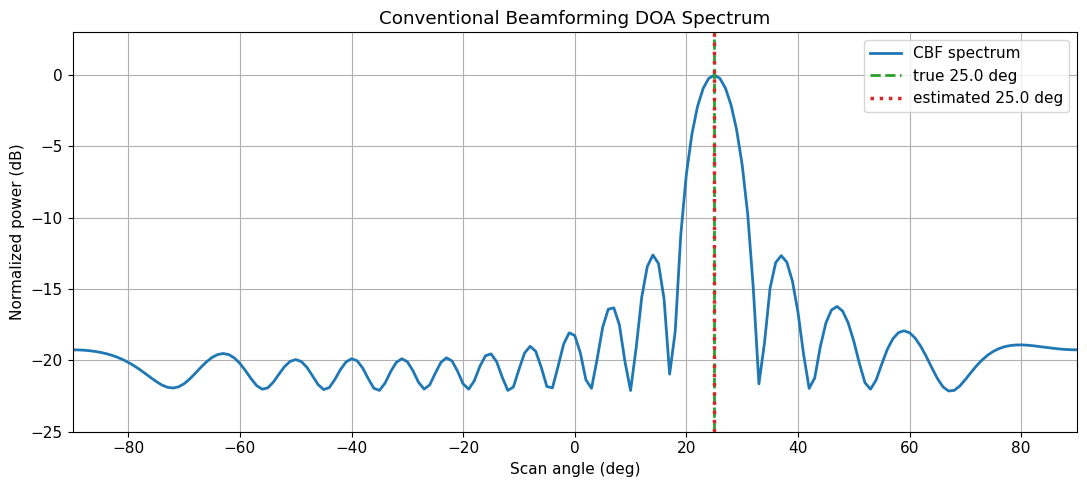

In [28]:
plt.figure(figsize=(11, 5))
plt.plot(scan_angles, power_db, linewidth=2, label="CBF spectrum")
plt.axvline(theta_true_deg, color="tab:green", linestyle="--", linewidth=2, label=f"true {theta_true_deg:.1f} deg")
plt.axvline(theta_hat, color="tab:red", linestyle=":", linewidth=2.5, label=f"estimated {theta_hat:.1f} deg")
plt.ylim(-25, 3)
plt.xlim(-90, 90)
plt.xlabel("Scan angle (deg)")
plt.ylabel("Normalized power (dB)")
plt.title("Conventional Beamforming DOA Spectrum")
plt.legend(loc="upper right")
plt.tight_layout()


## MVDR / Capon 波束形成

MVDR（Minimum Variance Distortionless Response）也叫 Capon 波束形成。  
它和 CBF 的核心区别是：CBF 只把扫描方向对齐后求输出功率；MVDR 会利用接收数据的协方差矩阵，主动压低其他方向的输出功率，同时保证目标扫描方向的响应不失真。

优化形式为：

$\min_{w} w^H R_{xx} w,\quad \mathrm{subject\ to}\ w^H a(\theta)=1$

解为：

$w_{\mathrm{mvdr}}(\theta)=\frac{R_{xx}^{-1}a(\theta)}{a(\theta)^H R_{xx}^{-1}a(\theta)}$

MVDR 空间谱通常写成：

$P_{\mathrm{mvdr}}(\theta)=\frac{1}{a(\theta)^H R_{xx}^{-1}a(\theta)}$

实际计算时不要直接求逆，优先用 `np.linalg.solve`。为了避免协方差矩阵病态，下面加入对角加载：

$R_{\mathrm{loaded}} = R_{xx} + \alpha \cdot \frac{\mathrm{trace}(R_{xx})}{M} \cdot I$


In [30]:
def mvdr_spectrum(X, scan_angles_deg, fc, c, positions, diagonal_loading=1e-3):
    """MVDR/Capon spatial spectrum over scan angles."""
    M = len(positions)
    Rxx = X @ X.conj().T / X.shape[1]

    # Diagonal loading improves numerical stability when Rxx is ill-conditioned.
    loading = diagonal_loading * np.trace(Rxx).real / M
    R_loaded = Rxx + loading * np.eye(M)

    A = np.column_stack([
        steering_vector(theta, fc, c, positions) for theta in scan_angles_deg
    ])

    # Solve R_loaded * Y = A instead of explicitly computing inv(R_loaded).
    Y = np.linalg.solve(R_loaded, A)
    denominator = np.real(np.sum(A.conj() * Y, axis=0))
    power = 1.0 / np.maximum(denominator, np.finfo(float).tiny)
    return power


mvdr_power = mvdr_spectrum(
    X=X,
    scan_angles_deg=scan_angles,
    fc=fc,
    c=c,
    positions=positions,
    diagonal_loading=1e-3,
)
mvdr_power_db = 10 * np.log10(mvdr_power / np.max(mvdr_power))

theta_hat_mvdr = scan_angles[np.argmax(mvdr_power)]
print(f"Estimated DOA by MVDR = {theta_hat_mvdr:.2f} deg")
print(f"Absolute error = {abs(theta_hat_mvdr - theta_true_deg):.2f} deg")


Estimated DOA by MVDR = 25.00 deg
Absolute error = 0.00 deg


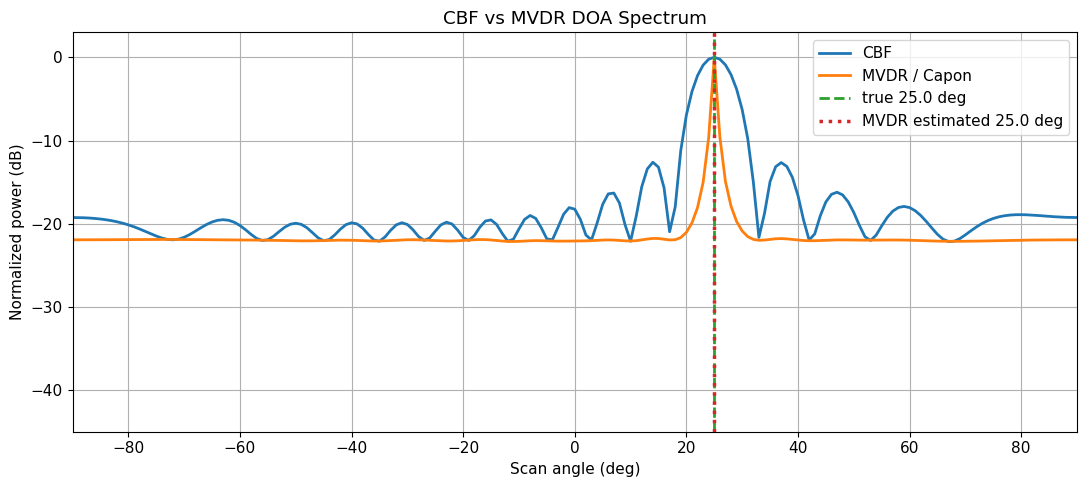

In [31]:
plt.figure(figsize=(11, 5))
plt.plot(scan_angles, power_db, linewidth=2, label="CBF")
plt.plot(scan_angles, mvdr_power_db, linewidth=2, label="MVDR / Capon")
plt.axvline(theta_true_deg, color="tab:green", linestyle="--", linewidth=2, label=f"true {theta_true_deg:.1f} deg")
plt.axvline(theta_hat_mvdr, color="tab:red", linestyle=":", linewidth=2.5, label=f"MVDR estimated {theta_hat_mvdr:.1f} deg")
plt.ylim(-45, 3)
plt.xlim(-90, 90)
plt.xlabel("Scan angle (deg)")
plt.ylabel("Normalized power (dB)")
plt.title("CBF vs MVDR DOA Spectrum")
plt.legend(loc="upper right")
plt.tight_layout()


## MVDR 观察要点

- MVDR 通常比 CBF 主瓣更窄，因此角度分辨能力更强。
- MVDR 依赖 `Rxx` 的估计质量；快拍数太少、信噪比太低或信号相关性太强时，谱可能不稳定。
- `diagonal_loading` 是实用工程里很常见的稳定化技巧；值太小可能矩阵病态，值太大则 MVDR 会逐渐退化得更像 CBF。
- 单个 CW 信号时，MVDR 和 CBF 的峰值都会接近真实角；差别主要体现在主瓣宽度和旁瓣/干扰抑制能力上。


## MUSIC 算法原理

MUSIC（Multiple Signal Classification）属于子空间类高分辨 DOA 估计算法。它的核心思想是：接收数据协方差矩阵可以分解为信号子空间和噪声子空间，真实来波方向的导向矢量 `a(theta)` 与噪声子空间近似正交。

阵列接收模型仍为：

$X = A S + W$

协方差矩阵为：

$R_{xx}=\frac{1}{N}XX^H$

对 `Rxx` 做特征值分解，较大的特征值对应信号子空间，较小的特征值对应噪声子空间。若信源数为 `K`，则噪声子空间为：

$E_n=[e_{K+1}, e_{K+2}, ..., e_M]$

MUSIC 空间谱定义为：

$P_{\mathrm{music}}(\theta)=\frac{1}{a(\theta)^H E_n E_n^H a(\theta)}$

当扫描角 `theta` 接近真实 DOA 时，`a(theta)` 与噪声子空间接近正交，分母变小，谱函数出现尖峰。

In [32]:
def music_spectrum(X, scan_angles_deg, fc, c, positions, num_sources):
    """MUSIC spatial spectrum over scan angles."""
    M = len(positions)
    Rxx = X @ X.conj().T / X.shape[1]

    # eigh is used because Rxx is Hermitian. Eigenvalues are returned in ascending order.
    eigvals, eigvecs = np.linalg.eigh(Rxx)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    En = eigvecs[:, num_sources:M]
    A = np.column_stack([
        steering_vector(theta, fc, c, positions) for theta in scan_angles_deg
    ])

    EnH_A = En.conj().T @ A
    denominator = np.sum(np.abs(EnH_A) ** 2, axis=0)
    power = 1.0 / np.maximum(denominator, np.finfo(float).tiny)
    return power, eigvals


# 当前 notebook 前面仿真的是单个 CW 信号，所以这里设 num_sources_music = 1。
num_sources_music = 1
music_power, music_eigvals = music_spectrum(
    X=X,
    scan_angles_deg=scan_angles,
    fc=fc,
    c=c,
    positions=positions,
    num_sources=num_sources_music,
)
music_power_db = 10 * np.log10(music_power / np.max(music_power))

theta_hat_music = scan_angles[np.argmax(music_power)]
print(f"Estimated DOA by MUSIC = {theta_hat_music:.2f} deg")
print(f"Absolute error = {abs(theta_hat_music - theta_true_deg):.2f} deg")
print("Largest eigenvalues:", np.round(music_eigvals[:4], 4))


Estimated DOA by MUSIC = 25.00 deg
Absolute error = 0.00 deg
Largest eigenvalues: [16.0822  0.1085  0.1077  0.1055]


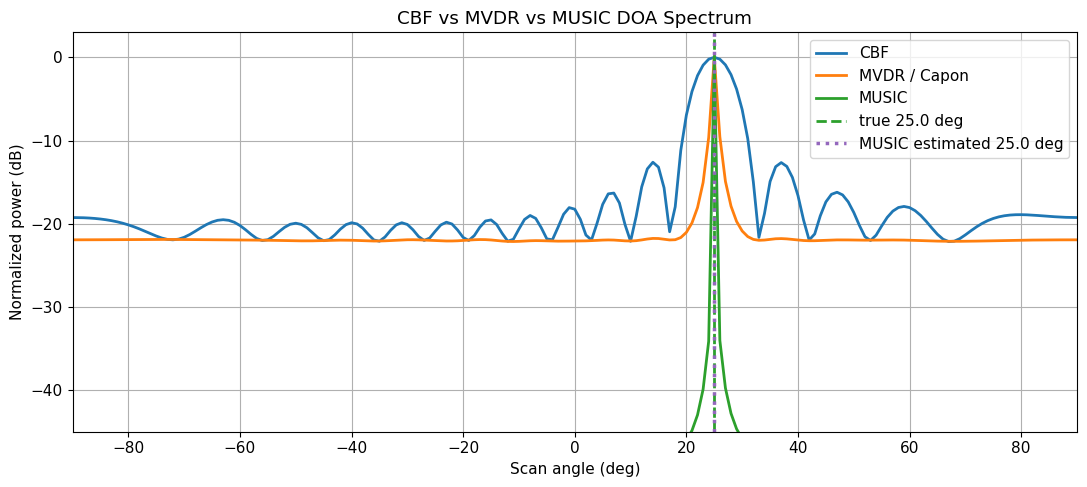

In [33]:
plt.figure(figsize=(11, 5))
plt.plot(scan_angles, power_db, linewidth=2, label="CBF")
plt.plot(scan_angles, mvdr_power_db, linewidth=2, label="MVDR / Capon")
plt.plot(scan_angles, music_power_db, linewidth=2, label="MUSIC")
plt.axvline(theta_true_deg, color="tab:green", linestyle="--", linewidth=2, label=f"true {theta_true_deg:.1f} deg")
plt.axvline(theta_hat_music, color="tab:purple", linestyle=":", linewidth=2.5, label=f"MUSIC estimated {theta_hat_music:.1f} deg")
plt.ylim(-45, 3)
plt.xlim(-90, 90)
plt.xlabel("Scan angle (deg)")
plt.ylabel("Normalized power (dB)")
plt.title("CBF vs MVDR vs MUSIC DOA Spectrum")
plt.legend(loc="upper right")
plt.tight_layout()


## MUSIC 观察要点

- MUSIC 的谱峰通常比 CBF/MVDR 更尖锐，因此具有更高的角度分辨潜力。
- MUSIC 需要预先知道或估计信源数 `K`；如果 `K` 设错，噪声子空间划分会错，谱峰可能失真。
- MUSIC 对协方差矩阵估计质量很敏感；快拍数太少、SNR 太低时性能会下降。
- 对相干源或强多径场景，普通 MUSIC 可能失效，常见补救方法是空间平滑或前后向平滑。
- 当前单源 CW baseline 中，MUSIC、MVDR、CBF 都应在真实角附近出现峰值，但 MUSIC 谱峰会更尖。


## 观察要点

- CBF 的峰值位置应该接近真实角 `theta_true_deg`。
- `M=16, d=lambda/2` 时不会出现明显栅瓣，但主瓣宽度仍然有限，所以 CBF 是稳健但分辨率不高的 baseline。
- 增大阵元数或孔径会变窄主瓣；降低 SNR 或减少快拍数会让谱峰更抖。
- 若把 `d` 改成 `lambda`，可能出现多个接近同等高度的峰，这就是空间混叠/栅瓣。
- 后续做 MUSIC 时，可以保留同一个 `X` 和 `steering_vector`，把谱函数换成子空间形式即可。

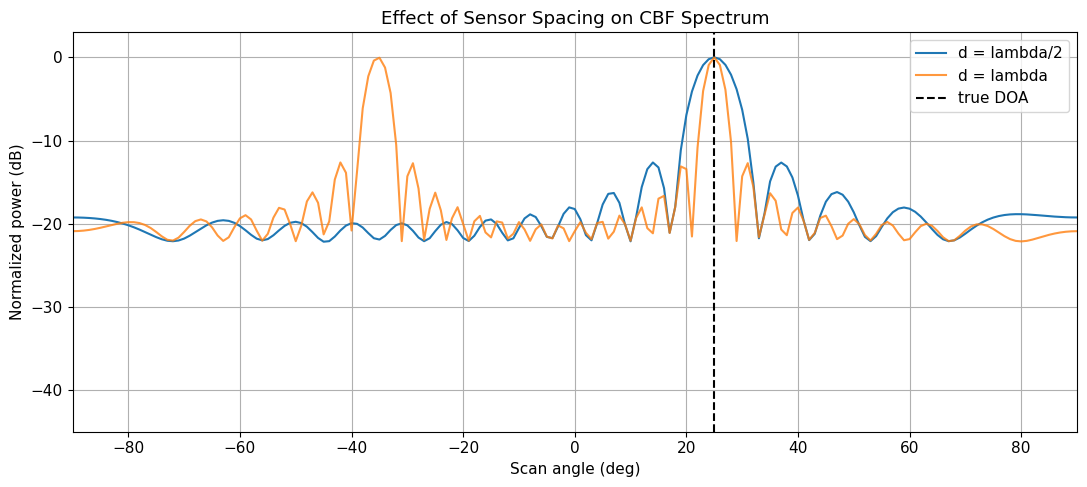

In [34]:
# Optional: compare half-wavelength spacing with one-wavelength spacing.
# This cell shows why d <= lambda/2 is the safe default for a ULA.

positions_half = np.arange(M) * (wavelength / 2)
positions_one = np.arange(M) * wavelength

a_half = steering_vector(theta_true_deg, fc, c, positions_half)
a_one = steering_vector(theta_true_deg, fc, c, positions_one)

X_half = add_complex_awgn(a_half[:, None] * s[None, :], snr_db, rng)
X_one = add_complex_awgn(a_one[:, None] * s[None, :], snr_db, rng)

p_half = cbf_spectrum(X_half, scan_angles, fc, c, positions_half)
p_one = cbf_spectrum(X_one, scan_angles, fc, c, positions_one)

p_half_db = 10 * np.log10(p_half / np.max(p_half))
p_one_db = 10 * np.log10(p_one / np.max(p_one))

plt.figure(figsize=(11, 5))
plt.plot(scan_angles, p_half_db, label="d = lambda/2")
plt.plot(scan_angles, p_one_db, label="d = lambda", alpha=0.8)
plt.axvline(theta_true_deg, color="k", linestyle="--", linewidth=1.5, label="true DOA")
plt.ylim(-45, 3)
plt.xlim(-90, 90)
plt.xlabel("Scan angle (deg)")
plt.ylabel("Normalized power (dB)")
plt.title("Effect of Sensor Spacing on CBF Spectrum")
plt.legend(loc="upper right")
plt.tight_layout()
